# Compile/Validate Output Length Analysis

This notebook analyzes cached pickle entries for the `compile` and `validate_tool` caches and compares output-string lengths (`len(outputs)`).

In [6]:
from pathlib import Path
import pickle
from dataclasses import dataclass

import pandas as pd
import matplotlib.pyplot as plt

# Adjust these paths if your cache root differs.
CACHE_ROOT = Path("/mnt/labstore/bespoke_olap/cache")
CACHE_DIRS = {
    "compile": CACHE_ROOT / "compile",
    "validate_tool": CACHE_ROOT / "validate_tool",
    "shell_tool": CACHE_ROOT / "shell",
}

# Optional: filter to cache files created on/after this date (YYYY-MM-DD), or set to None.
MIN_CREATED_DATE = None

In [7]:
@dataclass
class CacheRow:
    tool: str
    file: str
    created: str
    output_len: int
    output_is_none: bool
    success: object
    unpickle_ok: bool
    error: str


def _to_text_len(value) -> int:
    if value is None:
        return 0
    if isinstance(value, str):
        return len(value)
    return len(str(value))


def _safe_getattr(obj, key, default=None):
    return getattr(obj, key, default)


def _scan_cache_dir(tool: str, path: Path):
    rows = []
    if not path.exists():
        return rows

    for file_path in sorted(path.glob("*.pkl")):
        created = pd.Timestamp(file_path.stat().st_ctime, unit="s").isoformat()
        row = CacheRow(
            tool=tool,
            file=file_path.name,
            created=created,
            output_len=0,
            output_is_none=False,
            success=None,
            unpickle_ok=False,
            error="",
        )

        try:
            with open(file_path, "rb") as f:
                obj = pickle.load(f)

            outputs = _safe_getattr(obj, "outputs", None)
            row.output_is_none = outputs is None
            row.output_len = _to_text_len(outputs)
            row.success = _safe_getattr(
                obj, "success", _safe_getattr(obj, "succeeded", None)
            )
            row.unpickle_ok = True
        except Exception as e:
            row.error = str(e)

        rows.append(row.__dict__)

    return rows


rows = []
for tool_name, cache_dir in CACHE_DIRS.items():
    rows.extend(_scan_cache_dir(tool_name, cache_dir))

df = pd.DataFrame(rows)

if df.empty:
    print("No cache pickle files found. Check CACHE_ROOT/CACHE_DIRS.")
else:
    if MIN_CREATED_DATE is not None:
        df = df[df["created"] >= str(MIN_CREATED_DATE)].reset_index(drop=True)

    display(df.head(20))
    print(f"Total files: {len(df)}")
    print("By tool:")
    display(df.groupby("tool", dropna=False).size().rename("n_files").reset_index())

,tool,file,created,output_len,output_is_none,success,unpickle_ok,error
0,compile,001af59c584ea6beb9d4bb229d365407553033551ba59d...,2026-03-03T20:13:33.160196543,0,True,True,True,
1,compile,00fcbc96b866f4a5b7a57c652e9ddc0e8b05cfe51c8b5b...,2026-03-03T18:41:48.777158976,0,True,True,True,
2,compile,011156a7e2e76f7b7148f7961a4a2c3649ee4bd1a0e955...,2026-03-03T20:39:22.492073774,0,True,True,True,
3,compile,0114f1c7050b1130c4b598a5f349b6377dc1c4bd76b85b...,2026-03-04T23:24:08.500415324,0,True,True,True,
4,compile,0124cc27e4d27170272619b2813a18ed2e5239255c9e0c...,2026-03-03T16:13:52.596143723,0,True,True,True,
5,compile,01d1c5bc39628061dce13cbbd9099fb857ff7d53c4dbd0...,2026-03-04T21:19:23.973060608,0,True,True,True,
6,compile,027bfa430d21fc2230ef955fe6cc1caaec7bbb729a57ed...,2026-03-04T23:50:29.768980742,0,True,True,True,
7,compile,04e8bd2429a7277806733462f8a882bf25bea18dfd29d2...,2026-03-03T18:18:57.465647936,0,True,True,True,
8,compile,0693e7a1d8a74b41aa79a157699f2b91f1f69b178dc955...,2026-03-04T22:48:53.175269365,0,True,True,True,
9,compile,06b66dd300608bf1c6207d963e8b04fb5dad5591ecd5ca...,2026-03-04T21:54:22.984402180,0,True,True,True,


Total files: 2701
By tool:


,tool,n_files
0,compile,635
1,shell_tool,1364
2,validate_tool,702


In [8]:
if not df.empty:
    stats = (
        df.groupby("tool", dropna=False)["output_len"]
        .agg(["count", "min", "median", "mean", "max", "sum"])
        .reset_index()
        .sort_values("sum", ascending=False)
    )

    stats["mean"] = stats["mean"].round(2)
    display(stats)

    print("Unpickle failures:")
    display(
        df.groupby(["tool", "unpickle_ok"], dropna=False)
        .size()
        .rename("n")
        .reset_index()
        .sort_values(["tool", "unpickle_ok"], ascending=[True, False])
    )

    print("Largest outputs per tool:")
    topk = (
        df.sort_values(["tool", "output_len"], ascending=[True, False])
        .groupby("tool", dropna=False)
        .head(10)
        .reset_index(drop=True)
    )
    display(
        topk[
            [
                "tool",
                "file",
                "created",
                "output_len",
                "output_is_none",
                "success",
                "error",
            ]
        ]
    )

,tool,count,min,median,mean,max,sum
1,shell_tool,1364,130,4388.5,9023.12,229576,12307541
0,compile,635,0,0.0,1652.59,1019892,1049397
2,validate_tool,702,98,323.0,512.75,6683,359951


Unpickle failures:


,tool,unpickle_ok,n
0,compile,True,635
1,shell_tool,True,1364
2,validate_tool,True,702


Largest outputs per tool:


,tool,file,created,output_len,output_is_none,success,error
0,compile,0d99ef096091c84cce1e52c58ab6504063f4d073118711...,2026-03-03T23:19:09.755183935,1019892,False,False,
1,compile,bc1b09b66a2eded4ce1737fbb13d6961d71e4805b30154...,2026-03-04T20:53:14.679194689,11318,False,False,
2,compile,65292d3474fe4213663334ae7dfa8f45224272b49871ec...,2026-03-02T14:57:58.003216743,5374,False,False,
3,compile,efe075b2bbf7b1a9bf06cf425264e5c1c034b2d6953695...,2026-03-03T18:23:53.812515020,1100,False,False,
4,compile,f659c6c2601d771a39270e8df26b2571dba7020796ef9e...,2026-03-02T14:57:11.098520756,1012,False,False,
5,compile,892bc85967a9e995d925f3b98f1ea87c0eb75c6e43b403...,2026-03-04T20:53:54.890927553,976,False,False,
6,compile,2179da7a6733f750e31048c0bcf8f968e63b176426bf26...,2026-03-02T16:25:01.458276749,906,False,False,
7,compile,222675e6f400baf23970d64110cf5748b14d7d26ef25f0...,2026-03-04T22:58:56.317356348,895,False,False,
8,compile,1c5feffd9b0df328d7a8dccecc0adeb25009518ff0f627...,2026-03-02T15:37:20.716908455,891,False,False,
9,compile,422d552dae13f0cf7b799027a4a774b75cae6dcbab58ef...,2026-03-03T17:04:38.240008116,847,False,False,


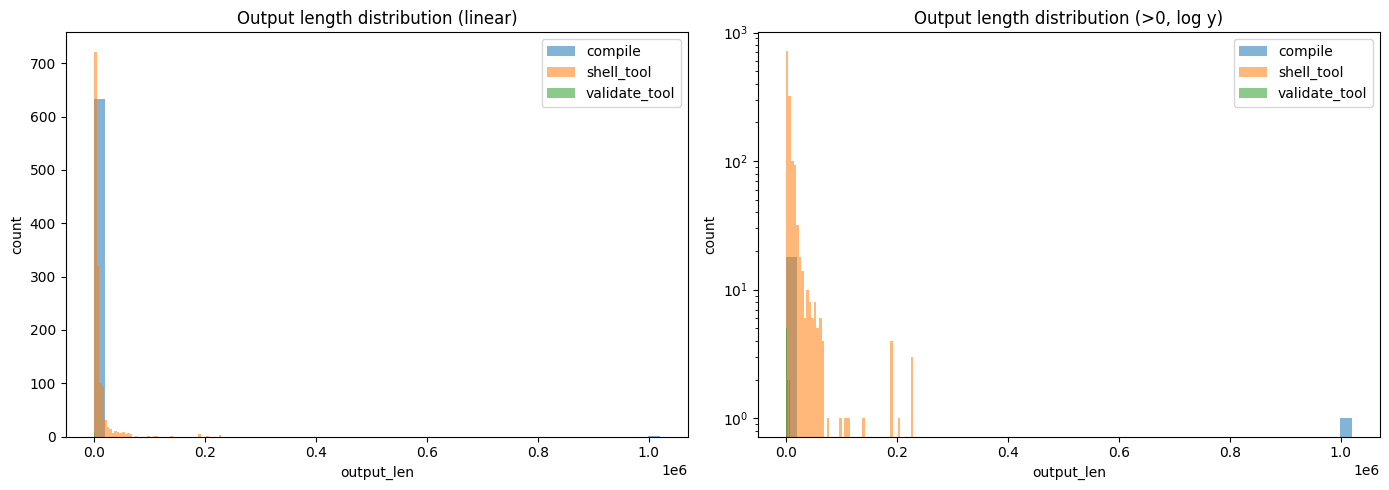

In [9]:
if not df.empty:
    tools = sorted(df["tool"].dropna().unique().tolist())

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Linear-scale histogram
    for tool in tools:
        vals = df.loc[df["tool"] == tool, "output_len"]
        axes[0].hist(vals, bins=50, alpha=0.55, label=tool)
    axes[0].set_title("Output length distribution (linear)")
    axes[0].set_xlabel("output_len")
    axes[0].set_ylabel("count")
    axes[0].legend()

    # Log-scale histogram (useful for long tails)
    for tool in tools:
        vals = df.loc[df["tool"] == tool, "output_len"]
        vals = vals[vals > 0]
        if len(vals) > 0:
            axes[1].hist(vals, bins=50, alpha=0.55, label=tool)
    axes[1].set_title("Output length distribution (>0, log y)")
    axes[1].set_xlabel("output_len")
    axes[1].set_ylabel("count")
    axes[1].set_yscale("log")
    axes[1].legend()

    plt.tight_layout()
    plt.show()